# Chapter 3 — Descriptive analysis (and the examples of Chapter 2)

Builds the 29 country graphs, computes their topological descriptors and produces Tables 1–2 and Figures 1–7. Requires the raw PyPSA-Eur tables in `data/pypsa_eur/` (see README). Runtime: a few minutes.

In [1]:
import os, sys, subprocess
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
ROOT = Path.cwd().parent            # the notebook lives in <root>/<chapter folder>/
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

def run(script, *args):
    """Run one script of this repository and print its output."""
    out = subprocess.run([sys.executable, script, *args], capture_output=True, text=True)
    print(out.stdout[-3000:] or out.stderr[-3000:])

def show(name, width=900):
    display(Image(filename=f'figures/{name}', width=width))

## Descriptors of the 29 grids and pan-European cross-check (Sections 3.2, 3.3)

In [2]:
run('01_descriptive/descriptive_metrics.py')
df = pd.read_csv('results/descriptive/descriptive_metrics.csv')
df[['country','n','m','k_mean','clustering','assortativity','avg_path_len','diameter','lambda2','frac_bridge']].round(3)

29 countries; assortativity negative in 22
{'n_europe': 5553, 'm_europe': 7224, 'bridges_europe': 1413, 'frac_bridges_europe': 0.19559800664451826, 'national_bridges': 1599, 'national_edges': 6959, 'still_bridges_in_europe': 1391, 'share_still_bridges': 0.8699186991869918}



,country,n,m,k_mean,clustering,assortativity,avg_path_len,diameter,lambda2,frac_bridge
0,AL,23,28,2.435,0.000,-0.028,3.324,7,0.168,0.321
1,LV,24,28,2.333,0.129,0.099,4.504,11,0.073,0.286
2,HR,24,27,2.250,0.149,-0.513,3.692,7,0.142,0.296
3,LT,27,32,2.370,0.123,0.189,4.923,12,0.058,0.094
4,DK,33,35,2.121,0.091,-0.197,5.464,13,0.054,0.543
5,BA,39,46,2.359,0.097,-0.179,4.139,10,0.074,0.391
6,GR,40,48,2.400,0.074,0.023,5.137,13,0.061,0.292
7,SK,47,55,2.340,0.043,-0.184,4.970,11,0.070,0.255
8,RS,51,66,2.588,0.098,-0.146,4.485,10,0.079,0.167
9,HU,55,71,2.582,0.036,-0.345,4.465,8,0.079,0.211


In [3]:
pd.read_csv('results/descriptive/pan_european_bridges.csv').T

,0
n_europe,5553.000000
m_europe,7224.000000
bridges_europe,1413.000000
frac_bridges_europe,0.195598
national_bridges,1599.000000
national_edges,6959.000000
still_bridges_in_europe,1391.000000
share_still_bridges,0.869919


## Tables 1 and 2

In [4]:
run('01_descriptive/tables_descriptive.py')
print(open('results/tables/table1_voltage_layers.tex').read()[:400])
print(open('results/tables/table2_descriptors.tex').read()[:400])

AL & 18 & 5 & 21 & 3 & 4 \\
LV & 0 & 24 & 0 & 0 & 28 \\
Albania & 23 & 28 & 2.43 & 0.000 & -0.028 & 3.32 & 7 & 0.168 & 32.1 \\
Latvia & 24 & 28 & 2.33 & 0.129 & 0.099 & 4.50 & 11 & 0.073 & 28.6 \\

AL & 18 & 5 & 21 & 3 & 4 \\
LV & 0 & 24 & 0 & 0 & 28 \\
HR & 18 & 6 & 19 & 3 & 5 \\
LT & 0 & 27 & 0 & 0 & 32 \\
DK & 5 & 28 & 3 & 2 & 30 \\
BA & 29 & 10 & 33 & 5 & 8 \\
GR & 0 & 40 & 0 & 0 & 48 \\
SK & 12 & 35 & 10 & 5 & 40 \\
RS & 26 & 25 & 31 & 10 & 25 \\
HU & 22 & 33 & 21 & 9 & 41 \\
IE & 52 & 4 & 62 & 4 & 3 \\
NL & 25 & 35 & 22 & 8 & 37 \\
CZ & 19 & 48 & 21 & 11 & 58 \\
BE & 26 & 45 & 26 & 7 &
Albania & 23 & 28 & 2.43 & 0.000 & -0.028 & 3.32 & 7 & 0.168 & 32.1 \\
Latvia & 24 & 28 & 2.33 & 0.129 & 0.099 & 4.50 & 11 & 0.073 & 28.6 \\
Croatia & 24 & 27 & 2.25 & 0.149 & -0.513 & 3.69 & 7 & 0.142 & 29.6 \\
Lithuania & 27 & 32 & 2.37 & 0.123 & 0.189 & 4.92 & 12 & 0.058 & 9.4 \\
Denmark & 33 & 35 & 2.12 & 0.091 & -0.197 & 5.46 & 13 & 0.054 & 54.3 \\
Bosnia and Herzegovina & 39 & 46 & 2.36 & 0.


## Figure 1 — real vs. synthetic Austrian grid (Section 2.1)

written /Users/mika/Desktop/BA/submission_code/figures/theory_austria_example.png | real n,m = 113 124 | sample n,m = 113 118



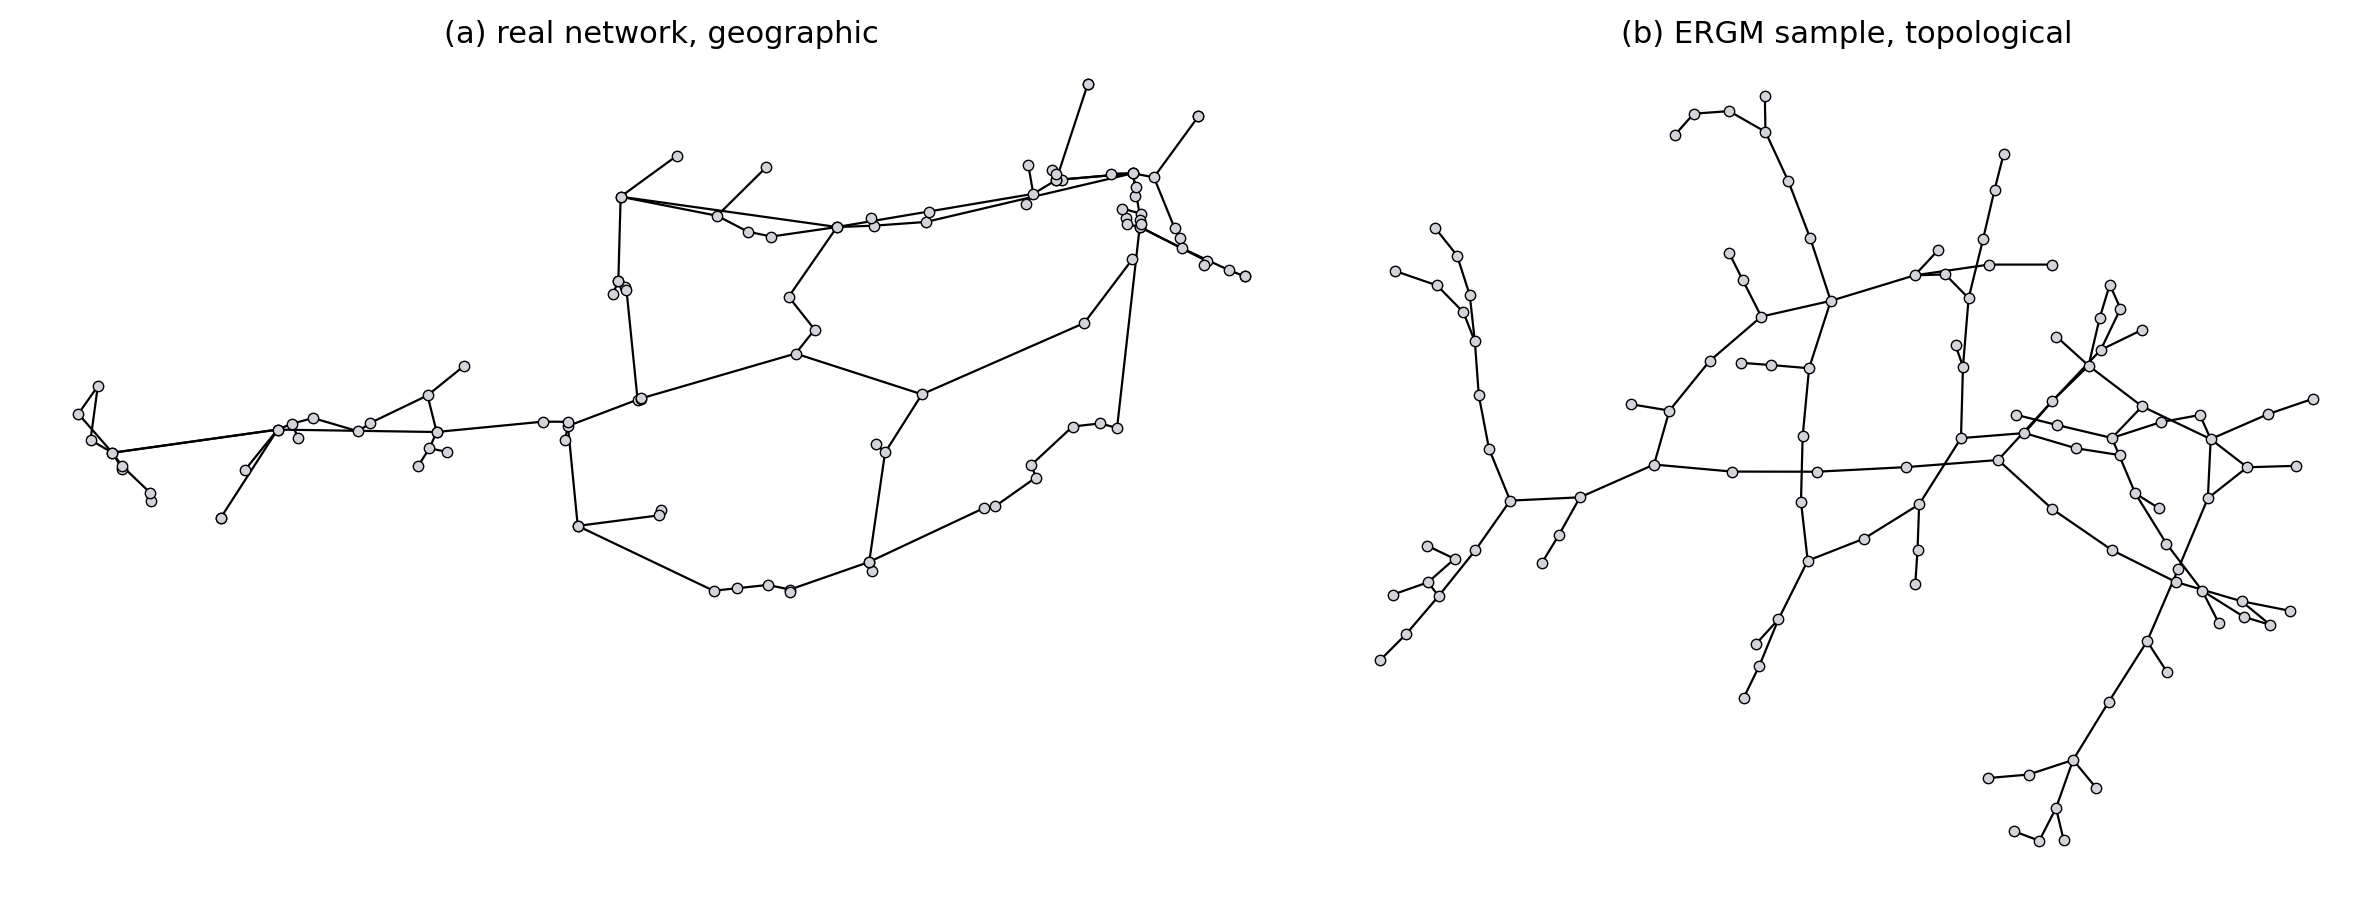

In [5]:
run('01_descriptive/fig1_austria_example.py'); show('theory_austria_example.png')

## Figure 2 — edge removal on the real Portuguese grid (Section 2.2)

written | random S at snaps [0.98, 0.91, 0.74] | attack S at snaps [0.99, 0.97, 0.49]



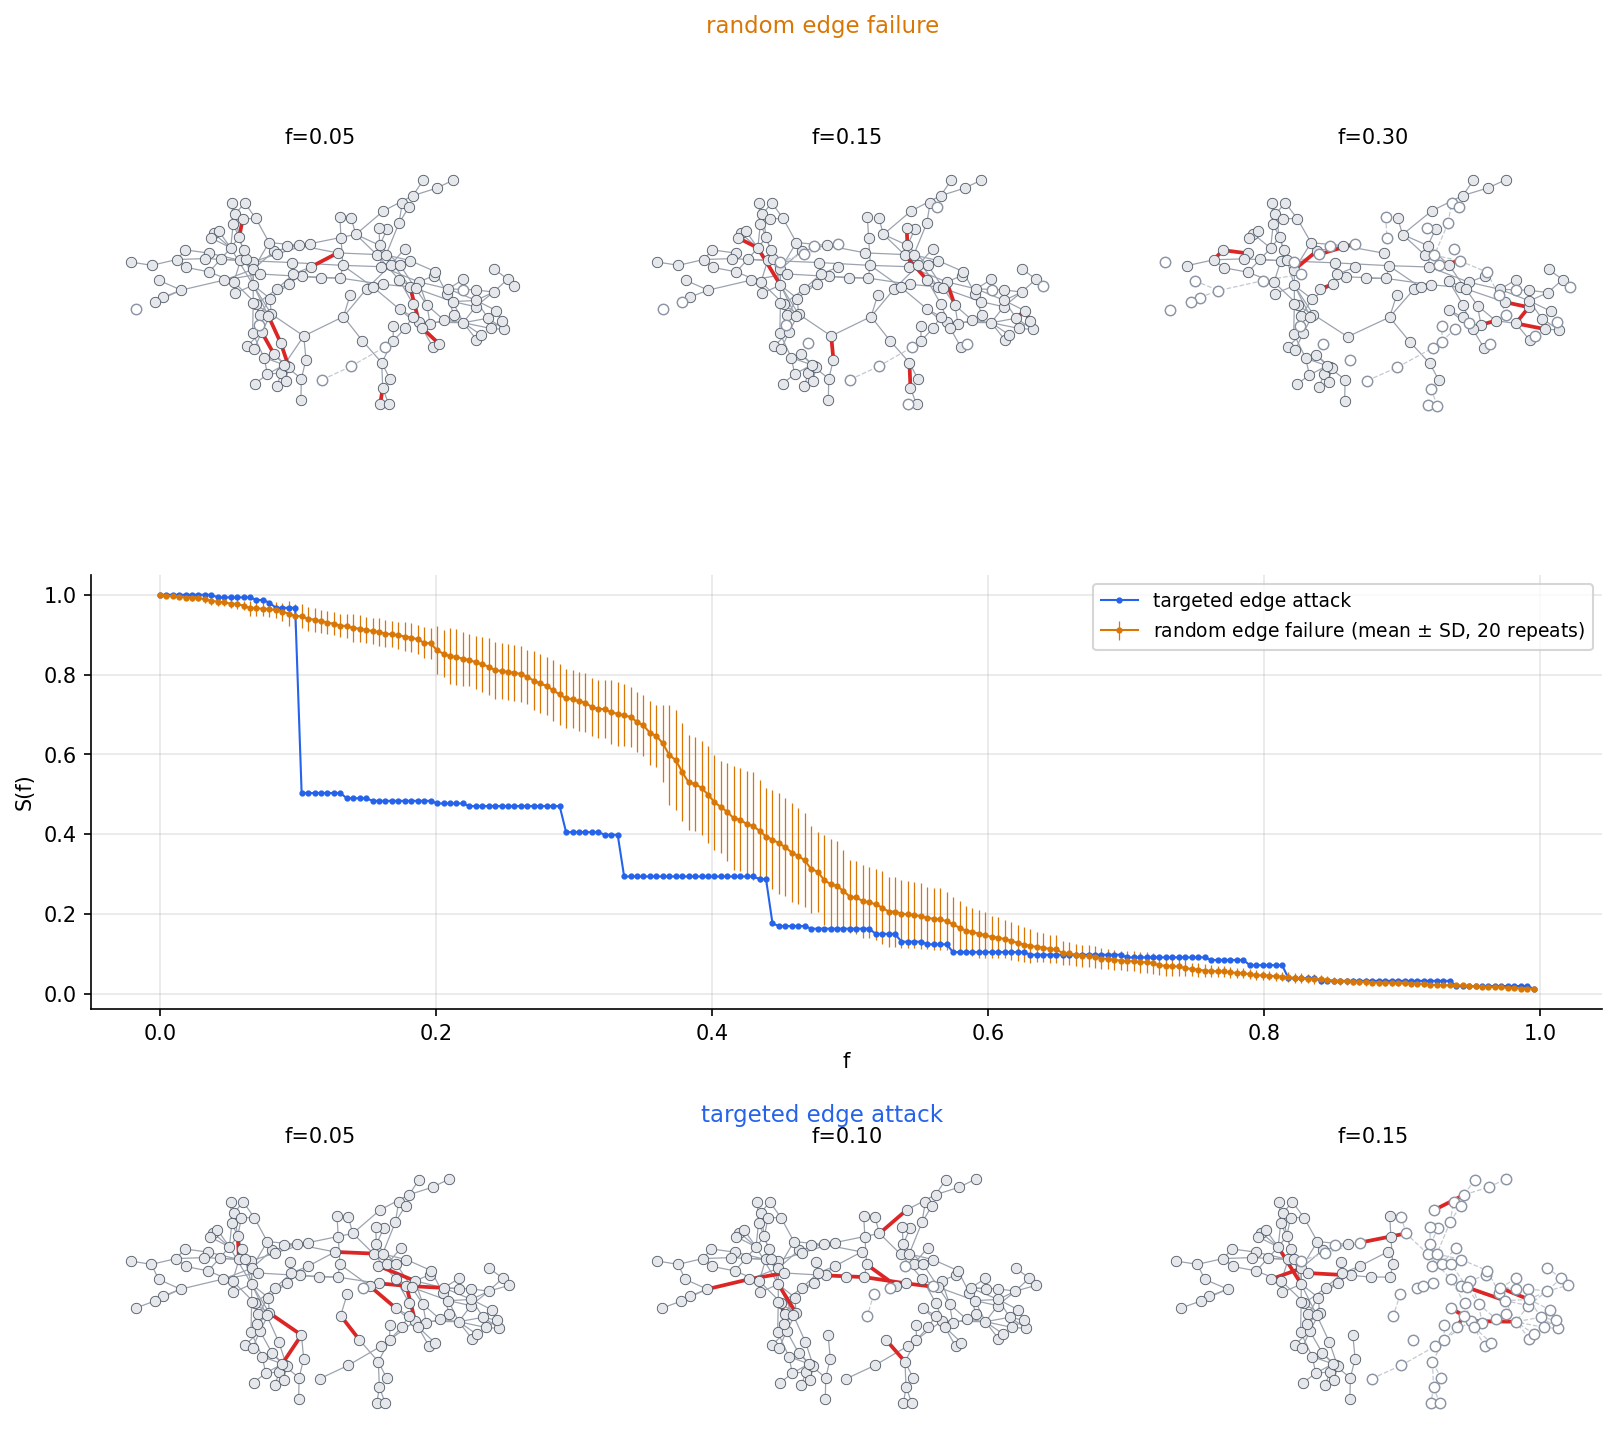

In [6]:
run('01_descriptive/fig2_edge_removal_example.py', 'PT'); show('robustness_edge_snapshots_PT.png', 700)

## Figure 3 — European grid map (Section 3.1)

pan-European graph: 6770 nodes, 8701 edges
written /Users/mika/Desktop/BA/submission_code/figures/descriptive_europe_map.png



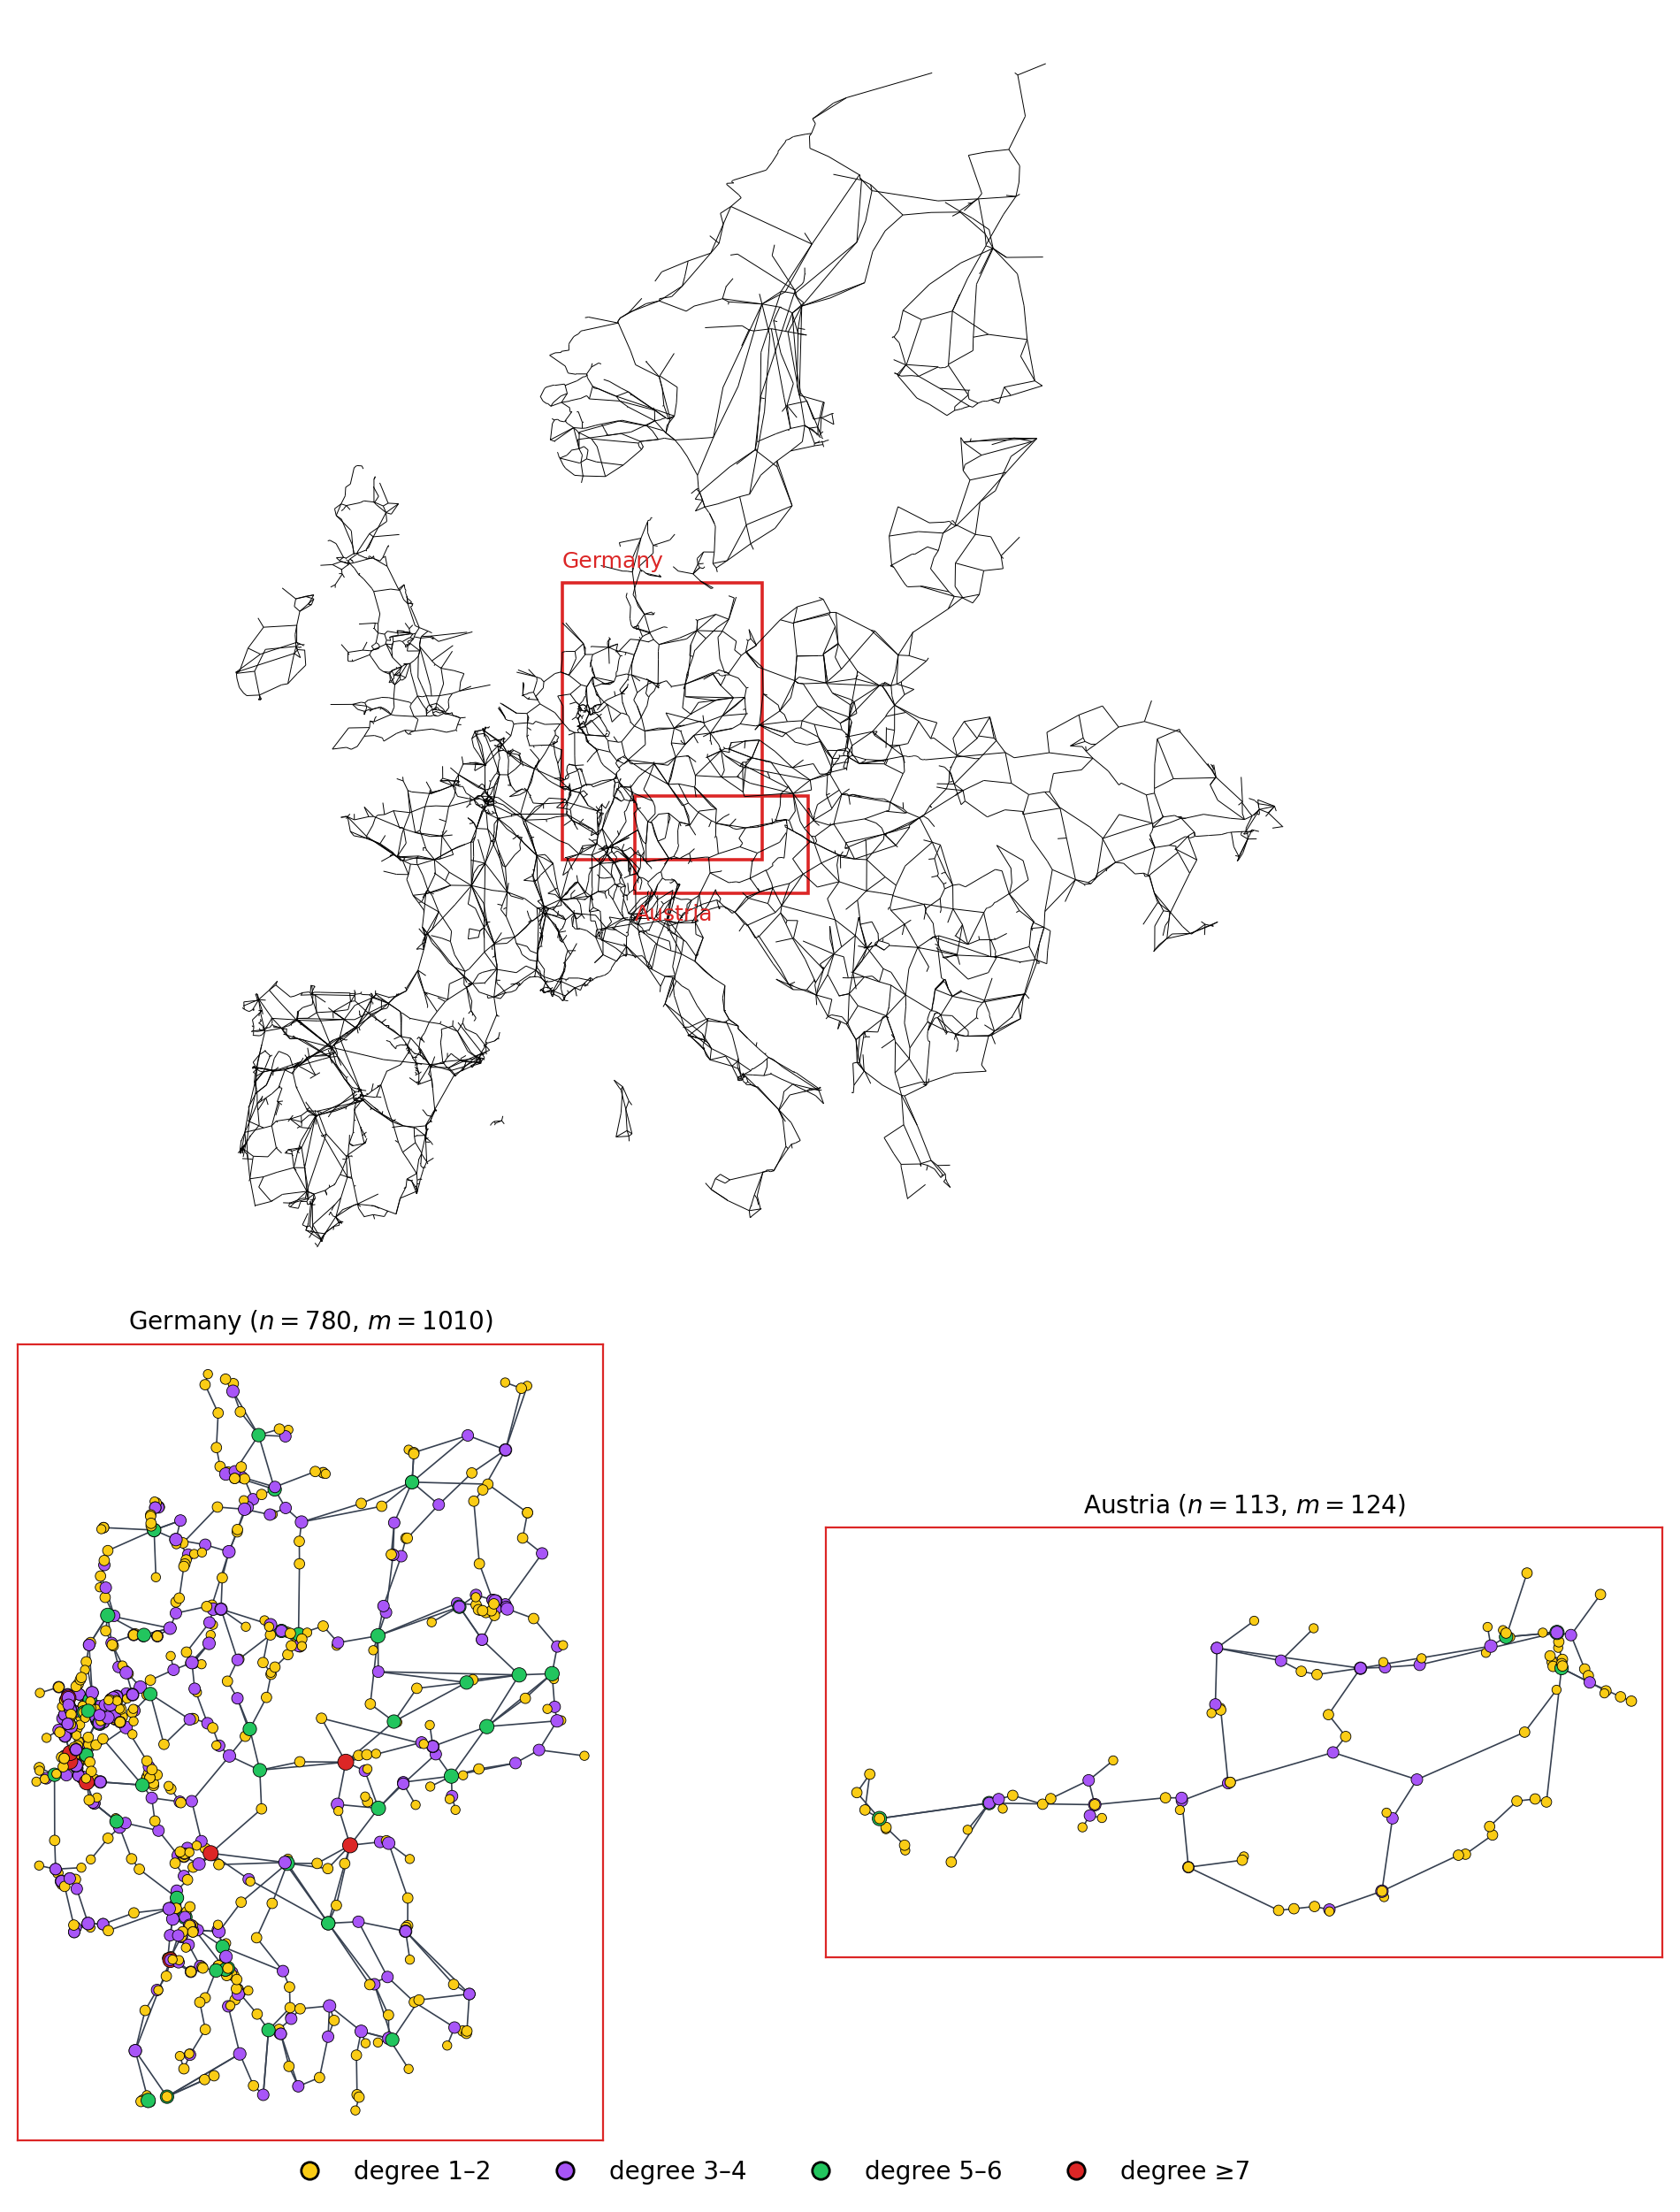

In [7]:
run('01_descriptive/fig3_europe_map.py'); show('descriptive_europe_map.png', 650)

## Figure 4 — number of edges vs. number of nodes (Section 3.3)

m = 1.283 n, R2 = 0.9969
written



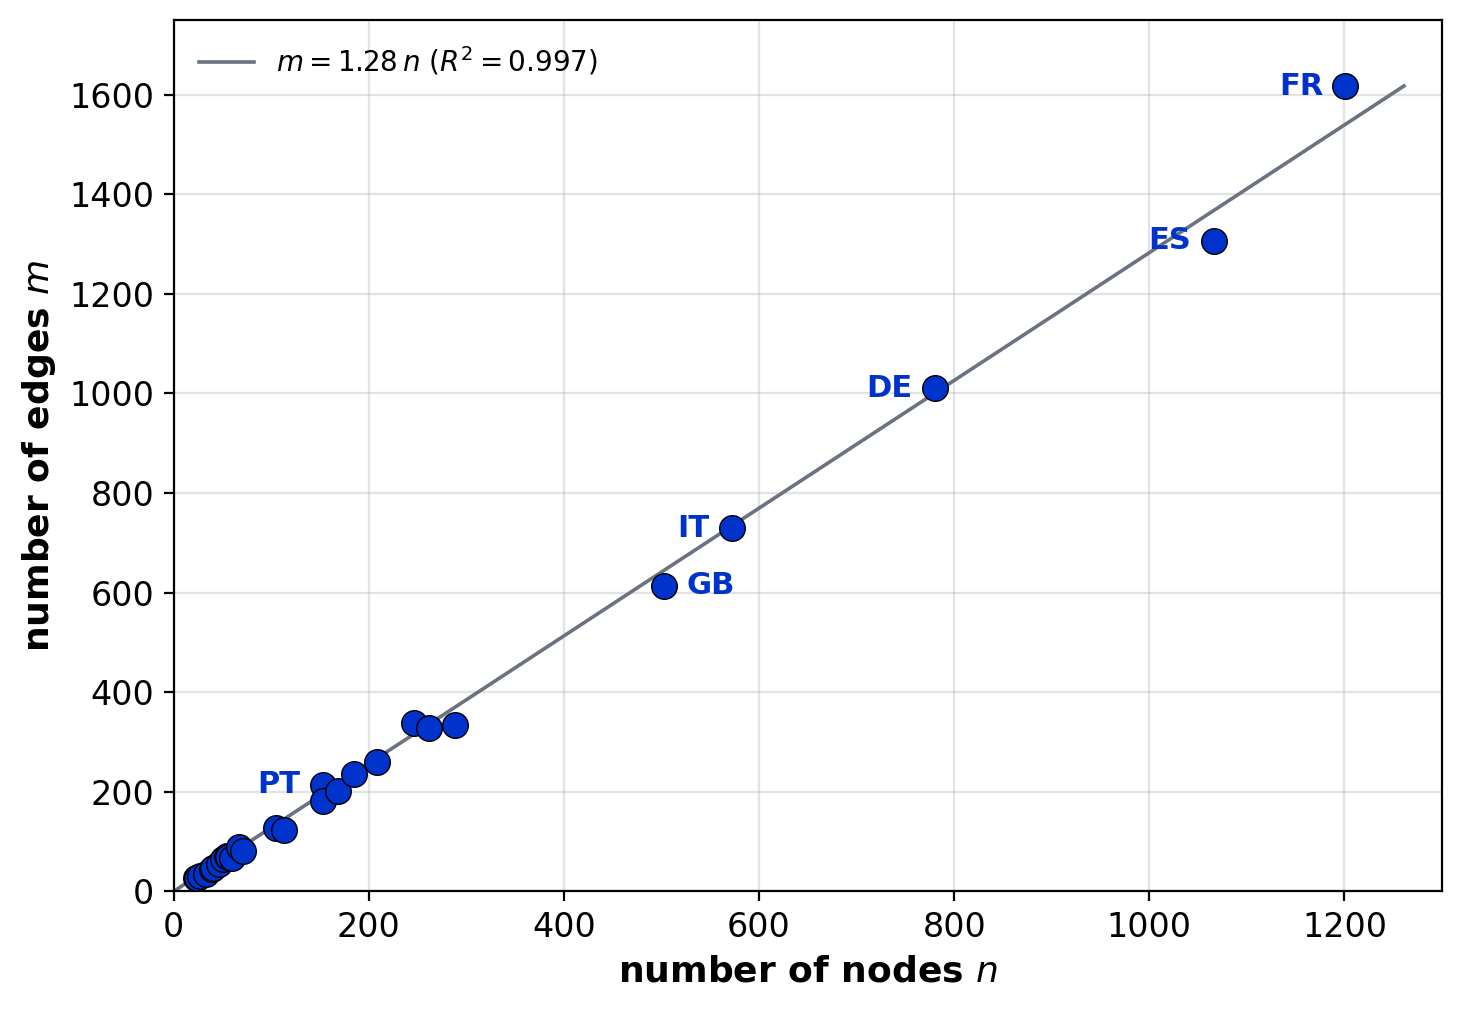

In [8]:
run('01_descriptive/fig4_size_scaling.py'); show('descriptive_size_scaling.png', 600)

## Figure 5 — degree distributions (Section 3.3)

pooled exponential fit: alpha=1.21, beta=0.71; k_max=10
written /Users/mika/Desktop/BA/submission_code/figures/descriptive_degree_distribution.png



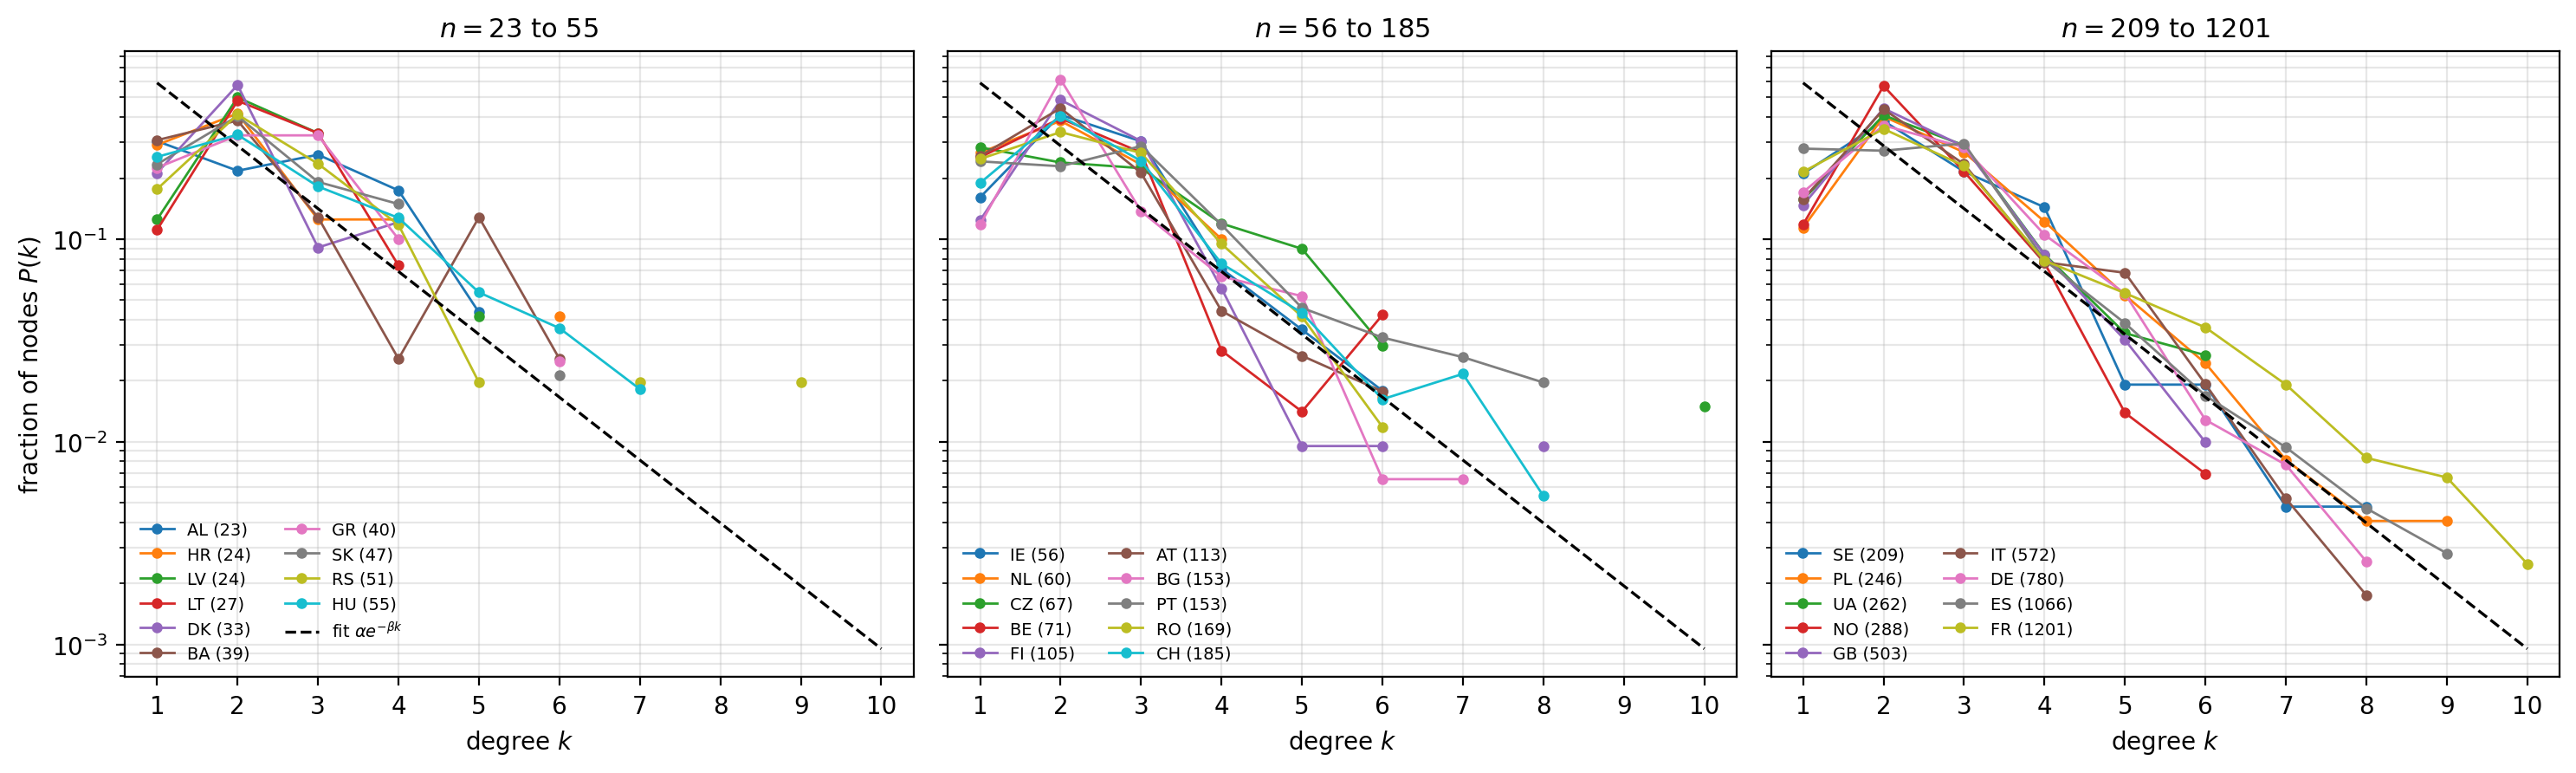

In [9]:
run('01_descriptive/fig5_degree_distribution.py'); show('descriptive_degree_distribution.png')

## Figure 6 — clustering coefficient (Section 3.3)

clustering: r=-0.19 p=0.33
written



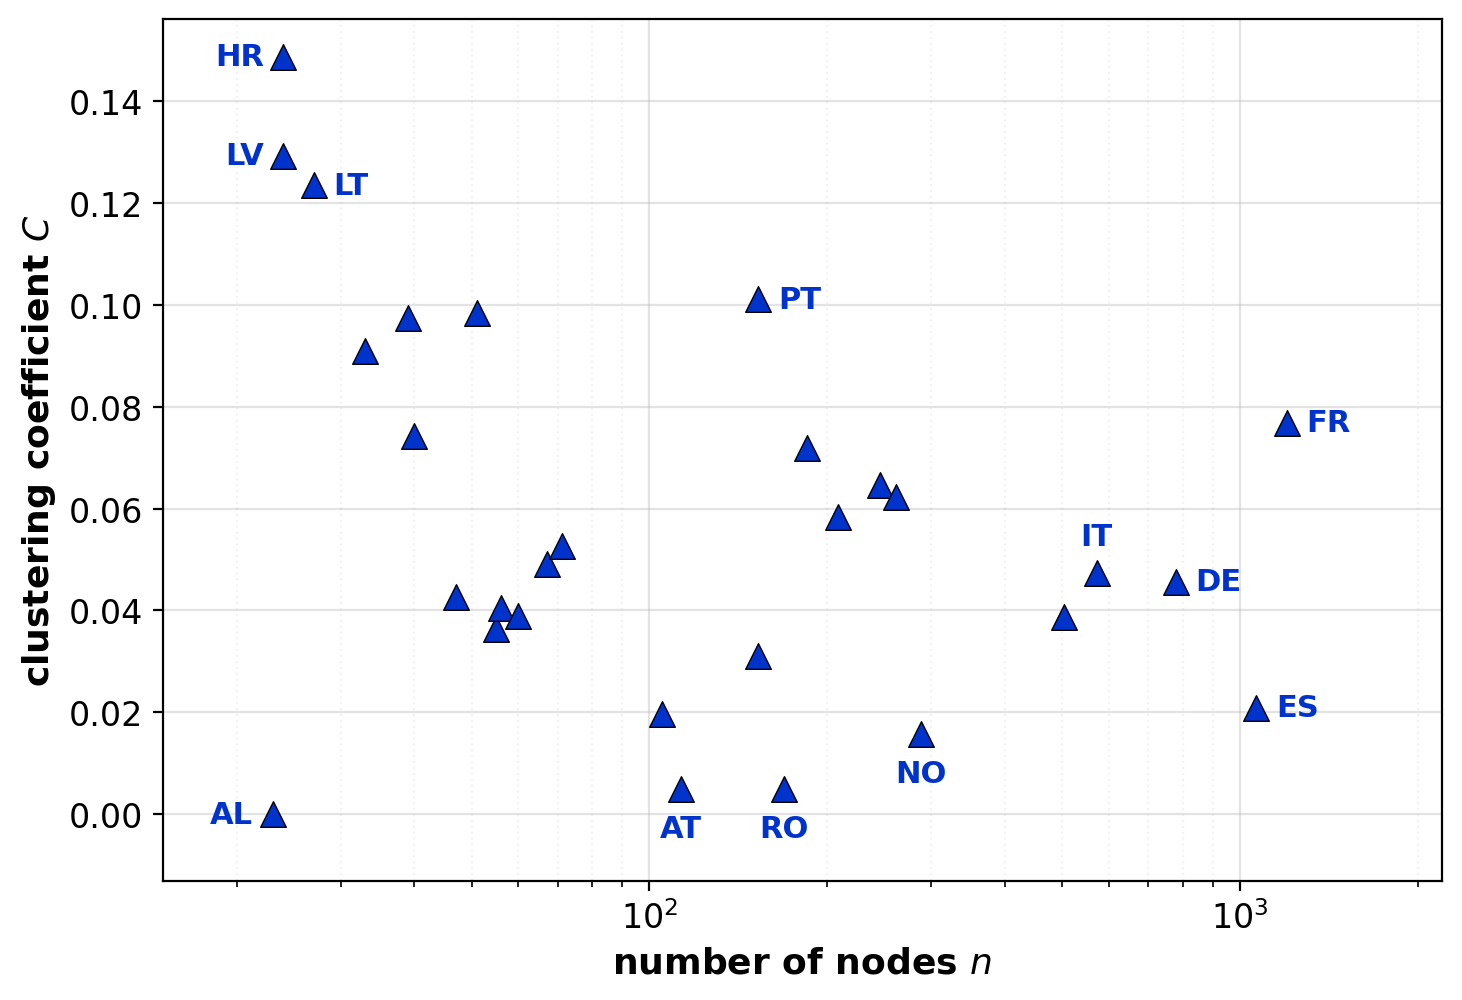

In [10]:
run('01_descriptive/fig6_clustering.py'); show('descriptive_clustering_vs_n.png', 600)

## Figure 7 — path length, diameter and algebraic connectivity (Section 3.3)

written



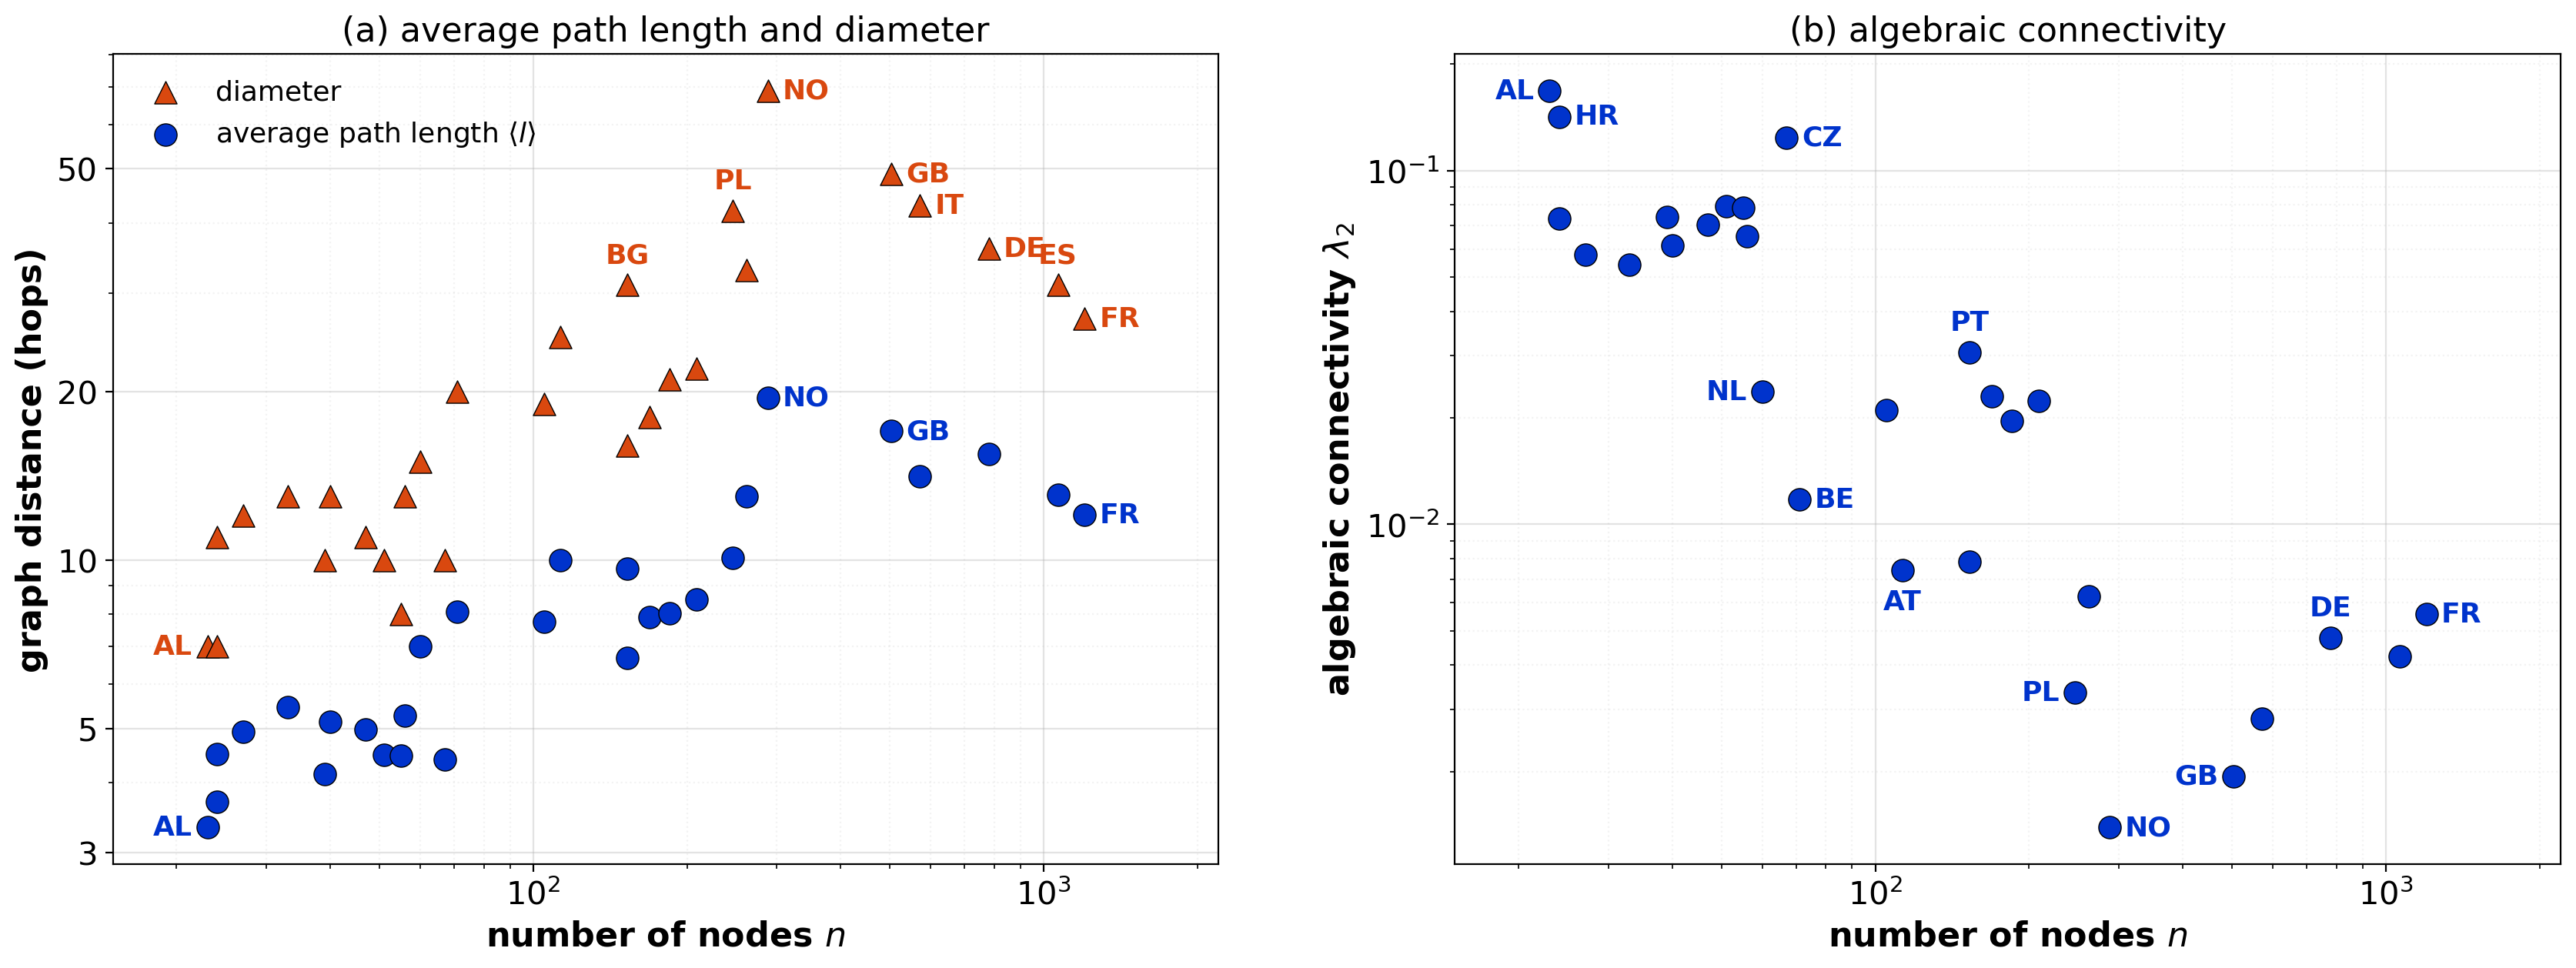

In [11]:
run('01_descriptive/fig7_path_length_lambda2.py'); show('descriptive_pathlength_lambda2.png')